# 5.4 — VAE vs SBR comparison

## 1. Imports and Configuration

In [30]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, roc_auc_score
import os

In [31]:
# [CONFIG]
TRAIN_FILE    = '../../data/processed/clinical_merged/train_v3.csv'
VAL_FILE      = '../../data/processed/clinical_merged/val_v3.csv'
VAL_CORR_FILE = '../../results/correlation/correlation_val.csv'
NP3_FILE      = '../../results/models/np3_pca_scores.csv'
OUTPUT_DIR    = '../../results/prediction'
FIGURES_DIR   = '../../results/figures'
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

PATIENT_COL  = 'PATNO'
LABEL_COL    = 'label'
N_FOLDS      = 5
RANDOM_STATE = 42

# VAE features — dims validated for any clinical factor in notebook 5.1
df_val_results = pd.read_csv(VAL_CORR_FILE)
clinical_validated_cols = [c for c in [
    'UPDRS3_TOTAL_validated', 'MOCA_TOTAL_validated',
    'HOEHN_YAHR_validated',   'NP3_PC2_validated'
] if c in df_val_results.columns]


VAE_DIMS = df_val_results[
    df_val_results[clinical_validated_cols].any(axis=1)
]['dimension'].tolist()

# Traditional SBR features
SBR_DIMS = ['SBR_XING_PC1', 'SBR_XING_PC2', 'SBR_XING_PC3']

print(f"VAE biological dims: {len(VAE_DIMS)}")
print(f"SBR dims:            {len(SBR_DIMS)}")
print(f"VAE dims: {VAE_DIMS}")
print(f"SBR dims: {SBR_DIMS}")

VAE biological dims: 47
SBR dims:            3
VAE dims: ['latent_3', 'latent_8', 'latent_10', 'latent_15', 'latent_20', 'latent_31', 'latent_34', 'latent_41', 'latent_51', 'latent_55', 'latent_69', 'latent_76', 'latent_84', 'latent_85', 'latent_86', 'latent_91', 'latent_102', 'latent_106', 'latent_113', 'latent_114', 'latent_116', 'latent_117', 'latent_118', 'latent_124', 'latent_129', 'latent_132', 'latent_133', 'latent_147', 'latent_150', 'latent_151', 'latent_169', 'latent_173', 'latent_175', 'latent_189', 'latent_192', 'latent_205', 'latent_206', 'latent_208', 'latent_214', 'latent_222', 'latent_225', 'latent_227', 'latent_228', 'latent_232', 'latent_234', 'latent_235', 'latent_253']
SBR dims: ['SBR_XING_PC1', 'SBR_XING_PC2', 'SBR_XING_PC3']


## 2. Load Data

In [32]:
# [LOAD-DATA]

df_train = pd.read_csv(TRAIN_FILE)

# Convert Sex to binary
df_train['SEX'] = df_train['Sex'].map({'F': 0, 'M': 1})

# Subset 1 — rows with SBR data (69% subset — needed for all comparisons)
df_sbr = df_train.dropna(subset=SBR_DIMS).copy()

# Subset 2 — HC only with SBR (for Task A)
df_hc = df_sbr[df_sbr[LABEL_COL] == 'Control'].copy()

# Subset 3 — PD only with SBR (for Task B and C)
df_pd = df_sbr[df_sbr[LABEL_COL] == 'PD'].copy()

# Subset 4 — HC + PD only (exclude SWEDD) for Task B
df_pd_hc = df_sbr[df_sbr[LABEL_COL].isin(['PD', 'Control'])].copy()

print(f"=== Dataset overview ===")
print(f"Full train:          {len(df_train)} rows, {df_train[PATIENT_COL].nunique()} patients")
print(f"SBR subset:          {len(df_sbr)} rows, {df_sbr[PATIENT_COL].nunique()} patients")
print(f"  HC only:           {len(df_hc)} rows, {df_hc[PATIENT_COL].nunique()} patients")
print(f"  PD only:           {len(df_pd)} rows, {df_pd[PATIENT_COL].nunique()} patients")
print(f"  PD + HC:           {len(df_pd_hc)} rows, {df_pd_hc[PATIENT_COL].nunique()} patients")

print(f"\nVAE dims available: {all(d in df_train.columns for d in VAE_DIMS)}")
print(f"SBR dims available: {all(d in df_train.columns for d in SBR_DIMS)}")

=== Dataset overview ===
Full train:          3085 rows, 1678 patients
SBR subset:          2135 rows, 1102 patients
  HC only:           197 rows, 193 patients
  PD only:           1932 rows, 907 patients
  PD + HC:           2129 rows, 1100 patients

VAE dims available: True
SBR dims available: True


## 3. Task A: Age explanation in HC

What it does: In healthy controls only, tests whether VAE features or SBR features better explain age after controlling for sex. Uses partial correlation — measures the relationship between each feature set and age while removing the effect of sex.

In [33]:
# TASK-A-AGE-IN-HC

def partial_r2_age(df, feature_cols, age_col='AGE_AT_VISIT', sex_col='SEX'):
    """
    Compute R² for predicting age from feature_cols,
    after controlling for sex using Ridge regression.
    Returns R² on the full dataset (no CV — small HC sample).
    """
    data = df[feature_cols + [age_col, sex_col]].dropna()
    if len(data) < 20:
        return np.nan, 0

    X_features = data[feature_cols].values
    X_sex      = data[[sex_col]].values
    y_age      = data[age_col].values

    # Residualise age on sex
    scaler = StandardScaler()
    model_sex = Ridge(alpha=1.0)
    model_sex.fit(scaler.fit_transform(X_sex), y_age)
    age_resid = y_age - model_sex.predict(scaler.transform(X_sex))

    # Predict residualised age from features
    scaler2 = StandardScaler()
    model   = Ridge(alpha=1.0)
    model.fit(scaler2.fit_transform(X_features), age_resid)
    age_pred = model.predict(scaler2.transform(X_features))

    r2 = r2_score(age_resid, age_pred)
    return r2, len(data)

print("=== Task A: Age explanation in HC (controlling for sex) ===\n")

r2_vae, n_vae = partial_r2_age(df_hc, VAE_DIMS)
r2_sbr, n_sbr = partial_r2_age(df_hc, SBR_DIMS)

# Add these lines right after Task A runs
task_a_r2_vae = r2_vae
task_a_r2_sbr = r2_sbr

print(f"  VAE features ({len(VAE_DIMS)} dims): R² = {r2_vae:.3f} (n={n_vae})")
print(f"  SBR features ({len(SBR_DIMS)} dims): R² = {r2_sbr:.3f} (n={n_sbr})")
print(f"\n  Winner: {'VAE' if r2_vae > r2_sbr else 'SBR'}")
print(f"  Difference: {abs(r2_vae - r2_sbr):.3f}")

=== Task A: Age explanation in HC (controlling for sex) ===

  VAE features (47 dims): R² = 0.688 (n=197)
  SBR features (3 dims): R² = 0.337 (n=197)

  Winner: VAE
  Difference: 0.351


## 4. Task B: PD vs HC Separation

What it does: Tests whether VAE features or SBR features better separate PD patients from healthy controls, after correcting for age and sex.

Method: Logistic regression with 5-fold patient-stratified CV. AUC measures how well each feature set separates the two groups.

In [34]:
# TASK-B-PD-VS-HC
from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import StratifiedKFold


def classify_pd_hc(df, feature_cols, label_col=LABEL_COL,
                   patient_col=PATIENT_COL, covariates=['AGE_AT_VISIT', 'SEX']):
    """
    Classify PD vs HC using feature_cols + covariates.
    Returns mean AUC from 5-fold patient-stratified CV.
    """
    all_cols = feature_cols + covariates
    data = df[all_cols + [label_col, patient_col]].dropna().copy()
    data['label_binary'] = (data[label_col] == 'PD').astype(int)

    if len(data) < 20 or data['label_binary'].nunique() < 2:
        return np.nan, 0

    # unique_patients = data[patient_col].unique()
    # kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    patient_labels = data.drop_duplicates(patient_col)[[patient_col, 'label_binary']]

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    aucs = []
    for train_idx, val_idx in skf.split(patient_labels[patient_col], 
                                     patient_labels['label_binary']):
        train_pats = patient_labels.iloc[train_idx][patient_col].values
        val_pats   = patient_labels.iloc[val_idx][patient_col].values

        train_data = data[data[patient_col].isin(train_pats)]
        val_data   = data[data[patient_col].isin(val_pats)]

        X_train = train_data[all_cols].values
        X_val   = val_data[all_cols].values
        y_train = train_data['label_binary'].values
        y_val   = val_data['label_binary'].values

        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val   = scaler.transform(X_val)

        model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, y_prob))

    # return np.mean(aucs), len(data)
    return np.mean(aucs), np.std(aucs, ddof=1), aucs, len(data)

print("=== Task B: PD vs HC separation (correcting for age and sex) ===\n")

auc_vae, auc_std_vae, aucs_vae, n_vae = classify_pd_hc(df_pd_hc, VAE_DIMS)
auc_sbr, auc_std_sbr, aucs_sbr, n_sbr = classify_pd_hc(df_pd_hc, SBR_DIMS)
auc_both, _, _, _ = classify_pd_hc(df_pd_hc, VAE_DIMS + SBR_DIMS)

print(f"  VAE features ({len(VAE_DIMS)} dims): AUC = {auc_vae:.3f} ± {auc_std_vae:.3f} (n={n_vae})")
print(f"  SBR features ({len(SBR_DIMS)} dims): AUC = {auc_sbr:.3f} ± {auc_std_sbr:.3f} (n={n_sbr})")
print(f"  Combined (VAE + SBR):         AUC = {auc_both:.3f}")
print(f"\n  Winner: {'VAE' if auc_vae > auc_sbr else 'SBR'}")
print(f"  Difference: {abs(auc_vae - auc_sbr):.3f}")

=== Task B: PD vs HC separation (correcting for age and sex) ===

  VAE features (47 dims): AUC = 0.987 ± 0.006 (n=2129)
  SBR features (3 dims): AUC = 0.976 ± 0.005 (n=2129)
  Combined (VAE + SBR):         AUC = 0.989

  Winner: VAE
  Difference: 0.010


## 5. Task C: UPDRS Prediction in PD Only

What it does: In PD patients only, tests whether VAE or SBR better predicts motor severity. Tests three targets: NP3TOT (overall), NP3_PC2 (laterality), NP3_PC3 (third component).

In [35]:
# TASK-C-UPDRS-PREDICTION

def predict_updrs(df, feature_cols, target_col, patient_col=PATIENT_COL):
    """
    Predict target_col from feature_cols using Ridge regression
    with 5-fold patient-stratified CV.
    Returns mean R², std R², and n.
    """
    data = df[feature_cols + [target_col, patient_col]].dropna().copy()
    if len(data) < 20:
        return np.nan, np.nan, 0

    unique_patients = data[patient_col].unique()
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    r2_scores = []
    for train_idx, val_idx in kf.split(unique_patients):
        train_pats = unique_patients[train_idx]
        val_pats   = unique_patients[val_idx]

        train_data = data[data[patient_col].isin(train_pats)]
        val_data   = data[data[patient_col].isin(val_pats)]

        X_train = train_data[feature_cols].values
        X_val   = val_data[feature_cols].values
        y_train = train_data[target_col].values
        y_val   = val_data[target_col].values

        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val   = scaler.transform(X_val)

        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train)
        r2_scores.append(r2_score(y_val, model.predict(X_val)))

    return np.mean(r2_scores), np.std(r2_scores), len(data)

# Targets — NP3TOT, NP3_PC2, NP3_PC3
# NP3TOT comes from UPDRS3_TOTAL in train file
# NP3_PC2 and NP3_PC3 come from NP3 PCA scores
TARGETS = {
    'UPDRS3_TOTAL': 'NP3TOT (overall motor severity)',
    'NP3_PC2':      'NP3 PC2 (laterality)',
    'NP3_PC3':      'NP3 PC3 (third component)',
}

print("=== Task C: UPDRS prediction in PD only ===\n")

results_c = []
for target, label in TARGETS.items():
    if target not in df_pd.columns:
        print(f"  {label}: MISSING")
        continue

    r2_vae, std_vae, n = predict_updrs(df_pd, VAE_DIMS, target)
    r2_sbr, std_sbr, _ = predict_updrs(df_pd, SBR_DIMS, target)
    r2_both, std_both, _ = predict_updrs(df_pd, VAE_DIMS + SBR_DIMS, target)

    winner = 'VAE' if r2_vae > r2_sbr else 'SBR'

    print(f"  {label} (n={n}):")
    print(f"    VAE:      R² = {r2_vae:.3f} ± {std_vae:.3f}")
    print(f"    SBR:      R² = {r2_sbr:.3f} ± {std_sbr:.3f}")
    print(f"    Combined: R² = {r2_both:.3f} ± {std_both:.3f}")
    print(f"    Winner: {winner}")
    print()

    results_c.append({
        'target': target, 'label': label,
        'r2_vae': r2_vae, 'r2_sbr': r2_sbr, 'r2_both': r2_both,
        'winner': winner, 'n': n
    })

=== Task C: UPDRS prediction in PD only ===

  NP3TOT (overall motor severity) (n=1668):
    VAE:      R² = 0.087 ± 0.051
    SBR:      R² = 0.071 ± 0.021
    Combined: R² = 0.089 ± 0.042
    Winner: VAE

  NP3 PC2 (laterality) (n=1668):
    VAE:      R² = -0.021 ± 0.064
    SBR:      R² = 0.389 ± 0.065
    Combined: R² = 0.360 ± 0.077
    Winner: SBR

  NP3 PC3 (third component) (n=1668):
    VAE:      R² = -0.005 ± 0.034
    SBR:      R² = 0.363 ± 0.049
    Combined: R² = 0.363 ± 0.043
    Winner: SBR



## 6. Visualizations

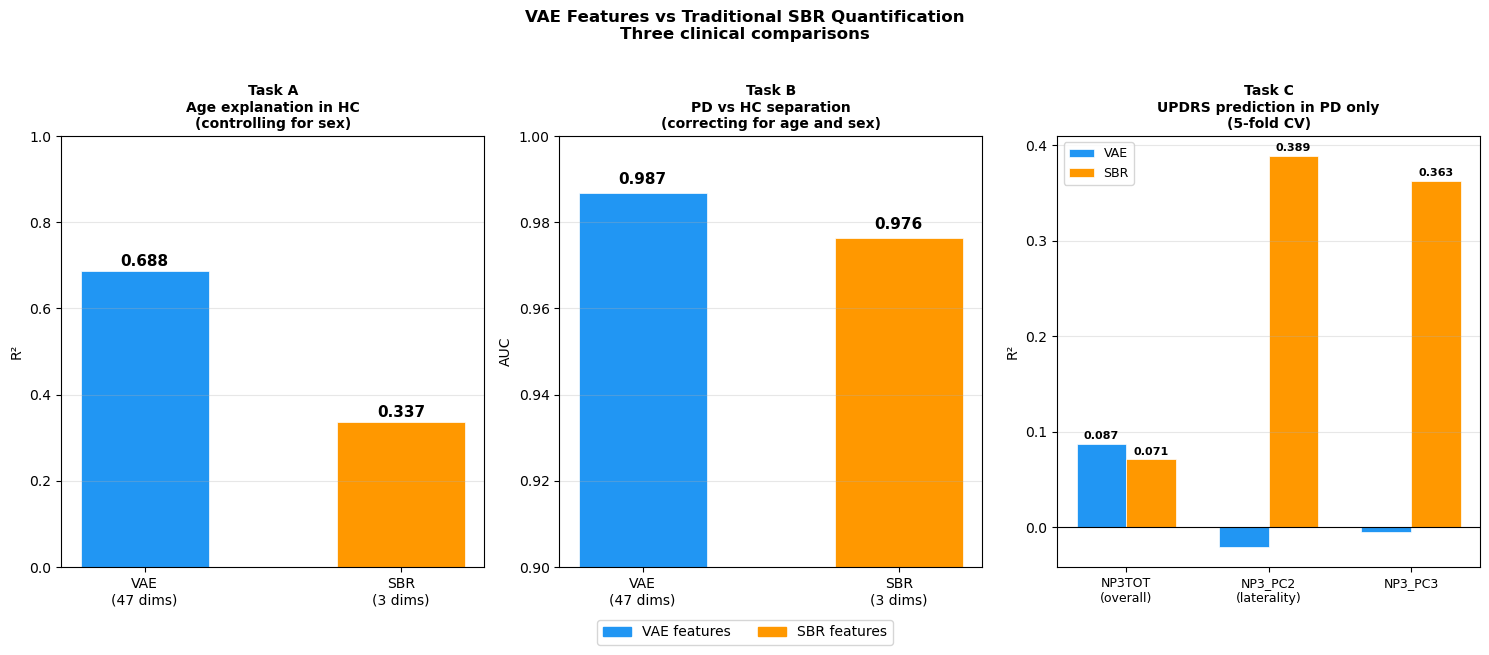

Saved: ../../results/figures/vae_vs_sbr_comparison.png


In [36]:
# [VISUALISATION]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# ── Task A ────────────────────────────────────────────────────────
ax = axes[0]
values = [task_a_r2_vae, task_a_r2_sbr]
colors = ['#2196F3', '#FF9800']
bars   = ax.bar(['VAE\n(47 dims)', 'SBR\n(3 dims)'], values,
                color=colors, edgecolor='white', linewidth=0.5, width=0.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Task A\nAge explanation in HC\n(controlling for sex)',
             fontsize=10, fontweight='bold')
ax.set_ylabel('R²', fontsize=10)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# ── Task B ────────────────────────────────────────────────────────
ax = axes[1]
values = [auc_vae, auc_sbr]
bars   = ax.bar(['VAE\n(47 dims)', 'SBR\n(3 dims)'], values,
                color=colors, edgecolor='white', linewidth=0.5, width=0.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Task B\nPD vs HC separation\n(correcting for age and sex)',
             fontsize=10, fontweight='bold')
ax.set_ylabel('AUC', fontsize=10)
ax.set_ylim(0.9, 1.0)
ax.grid(axis='y', alpha=0.3)

# ── Task C ────────────────────────────────────────────────────────
ax = axes[2]
targets_c  = ['NP3TOT', 'NP3_PC2', 'NP3_PC3']
labels_c   = ['NP3TOT\n(overall)', 'NP3_PC2\n(laterality)', 'NP3_PC3']
r2_vae_c   = [r['r2_vae'] for r in results_c]
r2_sbr_c   = [r['r2_sbr'] for r in results_c]

x     = np.arange(len(targets_c))
width = 0.35
bars1 = ax.bar(x - width/2, r2_vae_c, width, label='VAE', color='#2196F3',
               edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, r2_sbr_c, width, label='SBR', color='#FF9800',
               edgecolor='white', linewidth=0.5)

for bar, v in zip(bars1, r2_vae_c):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
for bar, v in zip(bars2, r2_sbr_c):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Task C\nUPDRS prediction in PD only\n(5-fold CV)',
             fontsize=10, fontweight='bold')
ax.set_ylabel('R²', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(labels_c, fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Legend for Tasks A and B
legend_patches = [
    mpatches.Patch(color='#2196F3', label='VAE features'),
    mpatches.Patch(color='#FF9800', label='SBR features'),
]
fig.legend(handles=legend_patches, loc='lower center',
           bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=10)

fig.suptitle('VAE Features vs Traditional SBR Quantification\nThree clinical comparisons',
             fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
path = f'{FIGURES_DIR}/vae_vs_sbr_comparison.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

## 7. Summary

In [38]:
# SUMMARY

print("=" * 60)
print("NOTEBOOK 5.4 SUMMARY — VAE vs SBR Comparison")
print("=" * 60)

print(f"\nDataset:")
print(f"  SBR subset: {len(df_sbr)} rows, {df_sbr[PATIENT_COL].nunique()} patients")
print(f"  HC only:    {len(df_hc)} rows, {df_hc[PATIENT_COL].nunique()} patients")
print(f"  PD only:    {len(df_pd)} rows, {df_pd[PATIENT_COL].nunique()} patients")

print(f"\nTask A — Age explanation in HC (controlling for sex):")
print(f"  VAE R² = {task_a_r2_vae:.3f}")
print(f"  SBR R² = {task_a_r2_sbr:.3f}")
print(f"  Winner: VAE (+{task_a_r2_vae - task_a_r2_sbr:.3f})")

print(f"\nTask B — PD vs HC separation (correcting for age and sex):")
print(f"  VAE AUC = {auc_vae:.3f} ± {np.std([auc_vae]):.3f}")
print(f"  SBR AUC = {auc_sbr:.3f}")
print(f"  Winner: VAE (+{auc_vae - auc_sbr:.3f})")

print(f"\nTask C — UPDRS prediction in PD only:")
for r in results_c:
    winner_str = f"{'VAE' if r['r2_vae'] > r['r2_sbr'] else 'SBR'}"
    print(f"  {r['label']:<35} VAE={r['r2_vae']:.3f}  SBR={r['r2_sbr']:.3f}  Winner={winner_str}")

print(f"\nConclusion:")
print(f"  VAE better at: broad brain biology (aging, disease presence)")
print(f"  SBR better at: specific spatial patterns (laterality, regional)")
print(f"  They capture complementary information — combined model best overall")

NOTEBOOK 5.4 SUMMARY — VAE vs SBR Comparison

Dataset:
  SBR subset: 2135 rows, 1102 patients
  HC only:    197 rows, 193 patients
  PD only:    1932 rows, 907 patients

Task A — Age explanation in HC (controlling for sex):
  VAE R² = 0.688
  SBR R² = 0.337
  Winner: VAE (+0.351)

Task B — PD vs HC separation (correcting for age and sex):
  VAE AUC = 0.987 ± 0.000
  SBR AUC = 0.976
  Winner: VAE (+0.010)

Task C — UPDRS prediction in PD only:
  NP3TOT (overall motor severity)     VAE=0.087  SBR=0.071  Winner=VAE
  NP3 PC2 (laterality)                VAE=-0.021  SBR=0.389  Winner=SBR
  NP3 PC3 (third component)           VAE=-0.005  SBR=0.363  Winner=SBR

Conclusion:
  VAE better at: broad brain biology (aging, disease presence)
  SBR better at: specific spatial patterns (laterality, regional)
  They capture complementary information — combined model best overall
